# Kaggle Notebook: Training Outfit Transformer
- Loads pre-prepared cropped dataset (from Notebook 1 / Kaggle Dataset)
- Trains compatibility & complementary models
- Comprehensive checkpointing (weights + optimizer + full metrics history)
- WandB integration with offline fallback
- Resume support across Kaggle sessions

In [1]:
import random
import numpy as np
import torch

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

!pip install -q torch torchvision transformers faiss-cpu gdown wandb

print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 56.4 MB/s eta 0:00:00
CUDA available: True
GPU count: 2


##  WandB Setup

In [2]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("WANDB_API_KEY")

In [3]:
import os
import glob

# List all files in /kaggle/working
files = glob.glob('/kaggle/working/*')
for f in files:
    if os.path.isfile(f):
        os.remove(f)
    elif os.path.isdir(f):
        import shutil
        shutil.rmtree(f)
print("Working directory cleared!")

Working directory cleared!


In [4]:
import wandb
import os
from datetime import datetime

try:
    from kaggle_secrets import UserSecretsClient
    secrets = UserSecretsClient()
    os.environ["WANDB_API_KEY"] = secrets.get_secret("WANDB_API_KEY")
    print("✅ WANDB_API_KEY loaded from Kaggle Secrets")
except Exception:
    print("⚠ Kaggle Secrets not available, WandB will run in offline mode")
    os.environ["WANDB_MODE"] = "offline"

wandb.init(
    project="fitfinder-outfit-transformer",
    config={
        "model_type": "clip",
        "polyvore_split": "disjoint",
        "image_only": True,
        "seed": seed,
        "n_epochs_compatibility": 10,
        "n_epochs_complementary": 10,
        "lr": 1e-3,
    },
    resume="allow",
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: moh000abdo (moh000abdo-alexandria-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ WANDB_API_KEY loaded from Kaggle Secrets


wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260516_013904-rlzynt1a
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run brisk-water-17
wandb: ⭐️ View project at https://wandb.ai/moh000abdo-alexandria-university/fitfinder-outfit-transformer
wandb: 🚀 View run at https://wandb.ai/moh000abdo-alexandria-university/fitfinder-outfit-transformer/runs/rlzynt1a


## Clone Repo, Verify Data & Patch Source Files

In [5]:
# Clone outfit-transformer
!git clone https://github.com/bigohofone/outfit-transformer.git


Cloning into 'outfit-transformer'...
remote: Enumerating objects: 1094, done.
remote: Counting objects: 100% (206/206), done.
remote: Compressing objects: 100% (74/74), done.
remote: Total 1094 (delta 162), reused 132 (delta 132), pack-reused 888 (from 2)
Receiving objects: 100% (1094/1094), 182.41 MiB | 39.89 MiB/s, done.
Resolving deltas: 100% (545/545), done.


In [6]:
%cd outfit-transformer

/kaggle/working/outfit-transformer


In [7]:
import sys
from pathlib import Path

# Verify prepared dataset exists
# Option A: From Kaggle Dataset input
DATASET_INPUTS = [
    Path("/kaggle/input/datasets/mabdelmoneim/polyvore-disjoint-cropped-garments"),
    Path("/kaggle/input/polyvore-disjoint-cropped-garments"),
]
# Option B: From previous notebook output (same session)
DATASET_WORKING = Path("/kaggle/working/cropped_polyvore")

PREPARED_DATA = None
for dataset_path in DATASET_INPUTS:
    if dataset_path.exists():
        PREPARED_DATA = dataset_path
        print(f"✅ Using Kaggle Dataset: {PREPARED_DATA}")
        break

if PREPARED_DATA is None and DATASET_WORKING.exists():
    PREPARED_DATA = DATASET_WORKING
    print(f"✅ Using working directory: {PREPARED_DATA}")

if PREPARED_DATA is None:
    raise FileNotFoundError(
        "Prepared dataset not found! Either:\n"
        "1. Attach 'polyvore-disjoint-cropped-garments' as a Kaggle Dataset, or\n"
        "2. Run Notebook 1 first in this same session."
    )

# Verify required directories
assert (PREPARED_DATA / "images").exists(), "images/ directory missing"
embeddings_dir = PREPARED_DATA / "embeddings_raw"
if not embeddings_dir.exists():
    embeddings_dir = PREPARED_DATA / "embeddings"
assert embeddings_dir.exists(), "embeddings/ directory missing"
print(f"  Images: {len(list((PREPARED_DATA / 'images').glob('*.png')))} files")
print(f"  Embeddings: {len(list(embeddings_dir.glob('*.npy')))} files")

✅ Using Kaggle Dataset: /kaggle/input/datasets/mabdelmoneim/polyvore-disjoint-cropped-garments
  Images: 251008 files
  Embeddings: 251008 files


In [8]:
USE_PREPARED_EMBEDDINGS = True
PREPARED_EMBEDDINGS_DIM = 512

In [9]:
# ── Download pre-trained checkpoints ──
!mkdir -p checkpoints
!gdown --id 1mzNqGBmd8UjVJjKwVa5GdGYHKutZKSSi -O checkpoints.zip
!unzip -q -o checkpoints.zip -d ./checkpoints
!rm -f checkpoints.zip

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1mzNqGBmd8UjVJjKwVa5GdGYHKutZKSSi
From (redirected): https://drive.google.com/uc?id=1mzNqGBmd8UjVJjKwVa5GdGYHKutZKSSi&confirm=t&uuid=ab36b8b6-f9cd-4d0e-9406-966284f3508f
To: /kaggle/working/outfit-transformer/checkpoints.zip
100%|██████████████████████████████████████| 1.15G/1.15G [00:12<00:00, 93.8MB/s]


### Patch source files
These patches are needed to support image_only mode and single-GPU training.
They modify the outfit-transformer source in-place.

In [10]:
# %cd outfit-transformer
# %cd ..
import re

In [11]:
# --- Patch 0: 1_generate_clip_embeddings.py (image_only support) ---
with open('src/run/1_generate_clip_embeddings.py', 'r') as f:
    content = f.read()

if "--image_only" not in content:
    content = content.replace(
        "parser.add_argument('--demo', action='store_true')",
        "parser.add_argument('--demo', action='store_true')\n"
        "    parser.add_argument('--image_only', action='store_true', default=False)"
    )

# Ensure image_only flows into load_model
content = re.sub(
    r"load_model\(([^\)]*?)checkpoint\s*=\s*args\.checkpoint([^\)]*?)\)",
    lambda m: (
        "load_model(" + m.group(1) + "checkpoint=args.checkpoint" + m.group(2) +
        ("" if "image_only" in m.group(0) else ", image_only=args.image_only") + ")"
    ),
    content,
    count=1
)

# Write embeddings to a dedicated image_only directory when enabled
content = content.replace(
    "POLYVORE_PRECOMPUTED_CLIP_EMBEDDING_DIR.format(polyvore_dir=args.polyvore_dir)",
    "POLYVORE_PRECOMPUTED_CLIP_EMBEDDING_DIR.format(polyvore_dir=args.polyvore_dir) + "
    "('_image_only' if args.image_only else '')"
)

with open('src/run/1_generate_clip_embeddings.py', 'w') as f:
    f.write(content)
print("✅ Patched 1_generate_clip_embeddings.py")

✅ Patched 1_generate_clip_embeddings.py


In [12]:
# --- Patch 0.5: outfit_transformer.py (concat approach for 512-dim precomputed embeddings) ---
# Instead of a linear adapter (512→1024), we concatenate the 512-dim image embedding
# with a learned 512-dim "no-text" embedding. This preserves the model's structure:
# the style encoder normalizes image/text halves separately.
with open('src/models/outfit_transformer.py', 'r') as f:
    content = f.read()

# Add image_only field to OutfitTransformerConfig
if 'image_only: bool = False' not in content:
    content = content.replace(
        '    d_embed: int = 128',
        '    d_embed: int = 128\n    image_only: bool = False'
    )

# Add learned no-text embedding for precomputed embeddings (512 params)
if 'precomputed_no_text_emb' not in content:
    content = content.replace(
        '    def _get_max_length(self, sequences):',
        '        # Learned "no-text" embedding for image-only precomputed embeddings\n'
        '        if getattr(self.cfg, "image_only", False):\n'
        '            half_dim = self.item_enc.d_embed // 2 if self.cfg.aggregation_method == "concat" else self.item_enc.d_embed\n'
        '            self.precomputed_no_text_emb = nn.Parameter(\n'
        '                torch.randn(half_dim) * 0.02, requires_grad=True\n'
        '            )\n\n'
        '    def _get_max_length(self, sequences):'
    )

# Insert _adapt_precomputed_embs call after loading precomputed embeddings
if '_adapt_precomputed_embs' not in content:
    content = content.replace(
        '            embs_of_outfit = torch.tensor(\n'
        '                np.array(embs_of_outfit[:max_length]), dtype=torch.float\n'
        '            ).to(self.device)\n',
        '            embs_of_outfit = torch.tensor(\n'
        '                np.array(embs_of_outfit[:max_length]), dtype=torch.float\n'
        '            ).to(self.device)\n'
        '            embs_of_outfit = self._adapt_precomputed_embs(embs_of_outfit)\n'
    )
    # Add the concat-based adaptation method
    content = content.replace(
        '    def _style_enc_forward(self, embs_of_inputs, src_key_padding_mask):',
        '    def _adapt_precomputed_embs(self, embs_of_outfit):\n'
        '        """Adapt precomputed embeddings to model dimension using concat."""\n'
        '        if embs_of_outfit.shape[-1] == self.item_enc.d_embed:\n'
        '            return embs_of_outfit  # already correct dimension\n'
        '        if not hasattr(self, "precomputed_no_text_emb"):\n'
        '            raise ValueError(\n'
        '                f"Precomputed embedding dim {embs_of_outfit.shape[-1]} != model dim {self.item_enc.d_embed}. "'
        '                f"Enable image_only=True to use the concat adapter."\n'
        '            )\n'
        '        # Concat image emb with learned no-text emb (preserves image/text split)\n'
        '        text_emb = self.precomputed_no_text_emb.unsqueeze(0).expand(embs_of_outfit.shape[0], -1)\n'
        '        return torch.cat([embs_of_outfit, text_emb], dim=-1)\n\n'
        '    def _style_enc_forward(self, embs_of_inputs, src_key_padding_mask):'
    )

with open('src/models/outfit_transformer.py', 'w') as f:
    f.write(content)
print("✅ Patched outfit_transformer.py (concat adapter)")

✅ Patched outfit_transformer.py (concat adapter)


In [13]:
# --- Patch 1: distributed_utils.py (single-GPU support) ---
dist_utils_content = '''import os
import torch
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP


def setup(rank, world_size):
    if world_size <= 1:
        return
    os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
    os.environ["MASTER_ADDR"] = "localhost"
    os.environ["MASTER_PORT"] = "12355"
    dist.init_process_group(backend="nccl", rank=rank, world_size=world_size)


def cleanup():
    if dist.is_initialized():
        dist.destroy_process_group()


def gather_results(all_loss, all_preds, all_labels):
    if not dist.is_initialized() or dist.get_world_size() == 1:
        return all_loss, all_preds, all_labels

    gathered_preds = [torch.empty_like(all_preds) for _ in range(dist.get_world_size())]
    gathered_labels = [torch.empty_like(all_labels) for _ in range(dist.get_world_size())]
    dist.all_gather(gathered_preds, all_preds)
    dist.all_gather(gathered_labels, all_labels)
    dist.all_reduce(all_loss, op=dist.ReduceOp.SUM)
    all_loss /= dist.get_world_size()
    gathered_preds = torch.cat(gathered_preds, dim=0)
    gathered_labels = torch.cat(gathered_labels, dim=0)
    return all_loss, gathered_preds, gathered_labels
'''

with open('src/utils/distributed_utils.py', 'w') as f:
    f.write(dist_utils_content)
print("✅ Patched distributed_utils.py")

✅ Patched distributed_utils.py


In [14]:
# --- Patch 2: encoder.py (image_only support) ---
encoder_content = '''from torch import nn
from typing import List, Dict, Any
import numpy as np
import torch
import torch.nn.functional as F

from ...data import datatypes
from .image_encoder import Resnet18ImageEncoder, CLIPImageEncoder
from .text_encoder import HuggingFaceTextEncoder, CLIPTextEncoder
from ...utils.model_utils import freeze_model, mean_pooling, aggregate_embeddings
from transformers import AutoModel, AutoTokenizer, AutoProcessor


class ItemEncoder(nn.Module):
    def __init__(
        self,
        model_name,
        enc_dim_per_modality,
        enc_norm_out,
        aggregation_method,
        image_only: bool = False
    ):
        super().__init__()
        self.enc_dim_per_modality = enc_dim_per_modality
        self.aggregation_method = aggregation_method
        self.enc_norm_out = enc_norm_out
        self.image_only = image_only
        self._build_encoders(model_name)

        if image_only:
            self.learned_no_text_emb = nn.Parameter(
                torch.randn(enc_dim_per_modality) * 0.02, requires_grad=True
            )

    def _build_encoders(self, model_name):
        self.image_enc = Resnet18ImageEncoder(
            embedding_size=self.enc_dim_per_modality,
        )
        self.text_enc = HuggingFaceTextEncoder(
            embedding_size=self.enc_dim_per_modality,
            model_name_or_path=model_name
        )

    @property
    def d_embed(self):
        if self.aggregation_method == "concat":
            return self.enc_dim_per_modality * 2
        else:
            return self.enc_dim_per_modality

    @property
    def image_size(self):
        return self.image_enc.image_size

    def forward(self, images, texts, *args, **kwargs):
        image_embeddings = self.image_enc(
            images, normalize=self.enc_norm_out, *args, **kwargs
        )

        if self.image_only:
            B, L, _ = image_embeddings.shape
            text_embeddings = (self.learned_no_text_emb
                .unsqueeze(0).unsqueeze(0)
                .expand(B, L, -1))
        else:
            text_embeddings = self.text_enc(
                texts, normalize=self.enc_norm_out, *args, **kwargs
            )

        encoder_outputs = aggregate_embeddings(
            image_embeddings=image_embeddings,
            text_embeddings=text_embeddings,
            aggregation_method=self.aggregation_method
        )
        return encoder_outputs


class CLIPItemEncoder(ItemEncoder):
    def __init__(
        self,
        model_name,
        enc_norm_out,
        aggregation_method,
        image_only: bool = False
    ):
        super().__init__(
            model_name=model_name,
            enc_dim_per_modality=512,
            enc_norm_out=enc_norm_out,
            aggregation_method=aggregation_method,
            image_only=image_only
        )

    def _build_encoders(self, model_name):
        self.image_enc = CLIPImageEncoder(
            model_name_or_path=model_name
        )
        self.text_enc = CLIPTextEncoder(
            model_name_or_path=model_name
        )
'''

with open('src/models/modules/encoder.py', 'w') as f:
    f.write(encoder_content)
print("✅ Patched encoder.py")

✅ Patched encoder.py


In [15]:
# --- Patch 2.5: load.py (FULL REWRITE for image_only + GPU + strict=False) ---
# The original load.py uses Korean comments that cause encoding issues with .replace()
# So we rewrite the entire file to guarantee correctness.
load_py_content = '''import torch
from typing import Any, Dict, Optional
from .outfit_transformer import (
    OutfitTransformerConfig, 
    OutfitTransformer
)
from .outfit_clip_transformer import (
    OutfitCLIPTransformerConfig,
    OutfitCLIPTransformer
)


def load_model(model_type, checkpoint=None, image_only=False, **cfg_kwargs):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # Load checkpoint if provided
    state_dict = None
    if checkpoint:
        state_dict = torch.load(checkpoint, map_location=device)
        cfg = state_dict.get('config', {})
        model_state_dict = state_dict.get('model', {})
    else:
        cfg = cfg_kwargs
        model_state_dict = None

    # Inject image_only into config (overrides checkpoint config)
    cfg['image_only'] = image_only

    # Initialize model
    if model_type == 'original':
        model = OutfitTransformer(OutfitTransformerConfig(**cfg))
    elif model_type == 'clip':
        model = OutfitCLIPTransformer(OutfitCLIPTransformerConfig(**cfg))
    else:
        raise ValueError(f"Unsupported model_type: {model_type}")

    model.to(device)

    # Load weights (strict=False to allow new params like precomputed_no_text_emb)
    if model_state_dict:
        new_state_dict = {}
        for k, v in model_state_dict.items():
            new_key = k.replace("module.", "")
            new_state_dict[new_key] = v

        missing, unexpected = model.load_state_dict(new_state_dict, strict=False)
        if missing:
            print(f"[Info] New params (not in checkpoint): {missing}")
        if unexpected:
            print(f"[Warning] Unexpected keys in state_dict: {unexpected}")
        print(f"Loaded model from checkpoint: {checkpoint}")

    return model
'''

with open('src/models/load.py', 'w') as f:
    f.write(load_py_content)
print("✅ Patched load.py (full rewrite: image_only + GPU + strict=False)")

✅ Patched load.py (full rewrite: image_only + GPU + strict=False)


In [16]:
# --- Patch 3: Polyvore dataset fix ---
with open('src/data/datasets/polyvore.py', 'r') as f:
    content = f.read()
content = content.replace(
    'metadata_idx2item_id = {\n    j: i for i, j in tqdm(enumerate(item_id2metadata_idx))\n}',
    'metadata_idx2item_id = {\n    i: j for i, j in enumerate(item_id2metadata_idx.keys())\n}'
)
if 'def load_metadata' not in content:
    content += "\n\n\ndef load_metadata(dataset_dir=None):\n    return globals().get('metadata')\n"
if 'def load_embedding_dict' in content and 'embeddings_raw' not in content:
    content += "\n\n# Patched: support .npy embeddings from prepared dataset\n"
    content += "def load_embedding_dict(dataset_dir):\n"
    content += "    pkl_dir = POLYVORE_PRECOMPUTED_CLIP_EMBEDDING_DIR.format(dataset_dir=dataset_dir)\n"
    content += "    if os.path.isdir(pkl_dir):\n"
    content += "        filenames = [f for f in os.listdir(pkl_dir) if f.endswith('.pkl')]\n"
    content += "        filenames = sorted(filenames, key=lambda x: int(x.split('.')[0].split('_')[-1]))\n"
    content += "        all_ids, all_embeddings = [], []\n"
    content += "        for filename in filenames:\n"
    content += "            filepath = os.path.join(pkl_dir, filename)\n"
    content += "            with open(filepath, 'rb') as f:\n"
    content += "                data = pickle.load(f)\n"
    content += "                all_ids += data['ids']\n"
    content += "                all_embeddings.append(data['embeddings'])\n"
    content += "        all_embeddings = np.concatenate(all_embeddings, axis=0)\n"
    content += "        return {item_id: emb for item_id, emb in zip(all_ids, all_embeddings)}\n"
    content += "\n"
    content += "    npy_dir = os.path.join(dataset_dir, 'embeddings_raw')\n"
    content += "    if not os.path.isdir(npy_dir):\n"
    content += "        npy_dir = os.path.join(dataset_dir, 'embeddings')\n"
    content += "    if os.path.isdir(npy_dir):\n"
    content += "        embedding_dict = {}\n"
    content += "        filenames = [f for f in os.listdir(npy_dir) if f.endswith('.npy')]\n"
    content += "        filenames = sorted(filenames)\n"
    content += "        total = len(filenames)\n"
    content += "        print(f'Loading {total} embeddings from {npy_dir} ...')\n"
    content += "        for idx, filename in enumerate(filenames):\n"
    content += "            if idx % 10000 == 0 and idx > 0:\n"
    content += "                print(f'  Loaded {idx}/{total} embeddings')\n"
    content += "            item_id = os.path.splitext(filename)[0]\n"
    content += "            embedding_dict[item_id] = np.load(os.path.join(npy_dir, filename))\n"
    content += "        print(f'  Loaded {total}/{total} embeddings')\n"
    content += "        return embedding_dict\n"
    content += "\n"
    content += "    raise FileNotFoundError(f'No embeddings found in {dataset_dir}')\n"

# Guard against empty or missing id_converter keys in HF splits
# Use a guaranteed approach: inject safe_load_item() that handles missing/empty keys
import re

# Ensure 'import random' is present
if 'import random' not in content:
    content = content.replace('import os', 'import os\nimport random', 1)

# Add safe_load_item function that handles missing/empty keys gracefully
if 'def safe_load_item' not in content:
    content = content.replace(
        'def load_item(',
        'def safe_load_item(item_id, id_converter, embedding_dict):\n'
        '    """Safely load item, skipping empty or missing IDs."""\n'
        '    if not item_id or item_id not in id_converter:\n'
        '        return None\n'
        '    return load_item(id_converter[item_id], embedding_dict)\n\n\n'
        'def load_item('
    )

# Replace all id_converter lookups with safe version
content = content.replace(
    'load_item(self.id_converter[item_id], self.embedding_dict)',
    'safe_load_item(item_id, self.id_converter, self.embedding_dict)'
)

# Filter out None items in outfit/candidate lists for compatibility
content = content.replace(
    'query=FashionCompatibilityQuery(outfit=outfit)',
    'query=FashionCompatibilityQuery(outfit=[x for x in outfit if x is not None])'
)
# Filter out None items for FITB candidates
content = content.replace(
    'return FashionFillInTheBlankData(\n'
    '            query=FashionComplementaryQuery(outfit=outfit, category=candidates[label].category),\n'
    '            label=label,\n'
    '            candidates=candidates\n'
    '        )',
    'candidates = [x for x in candidates if x is not None]\n'
    '        outfit = [x for x in outfit if x is not None]\n'
    '        if not candidates or label >= len(candidates):\n'
    '            return self.__getitem__(random.randint(0, len(self.data) - 1))\n'
    '        return FashionFillInTheBlankData(\n'
    '            query=FashionComplementaryQuery(outfit=outfit, category=candidates[label].category),\n'
    '            label=label,\n'
    '            candidates=candidates\n'
    '        )'
)
print("  Applied safe_load_item() to all id_converter lookups")

with open('src/data/datasets/polyvore.py', 'w') as f:
    f.write(content)
print("✅ Patched polyvore.py")

  Applied safe_load_item() to all id_converter lookups
✅ Patched polyvore.py


In [17]:
# --- Patch 4: Training scripts (standalone fallback + dist.barrier fix) ---
# These patches fix the standalone scripts for safety, but we use inline training below.
for filepath in ['src/run/2_train_compatibility.py', 'src/run/3_train_complementary.py']:
    with open(filepath, 'r') as f:
        content = f.read()

    # Fix dist.barrier() crash when not initialized
    content = content.replace(
        'dist.barrier()',
        'if dist.is_initialized(): dist.barrier()'
    )

    # Fix mp.spawn for world_size=1: call train() directly
    content = content.replace(
        "mp.spawn(\n        train, args=(args.world_size, args, wandb_run), \n        nprocs=args.world_size, join=True\n    )",
        "if args.world_size == 1:\n        train(0, args.world_size, args, wandb_run)\n    else:\n        mp.spawn(\n            train, args=(args.world_size, args, wandb_run), \n            nprocs=args.world_size, join=True\n        )"
    )

    with open(filepath, 'w') as f:
        f.write(content)
    print(f"✅ Patched {filepath} (dist.barrier + mp.spawn fix)")

print("\n✅ All source patches applied successfully")

✅ Patched src/run/2_train_compatibility.py (dist.barrier + mp.spawn fix)
✅ Patched src/run/3_train_complementary.py (dist.barrier + mp.spawn fix)

✅ All source patches applied successfully


## CheckpointManager

In [18]:
import time


class CheckpointManager:
    """Manages training checkpoints with full metrics history and WandB logging."""

    def __init__(self, save_dir="/kaggle/working/checkpoints", task_name="compatibility"):
        self.save_dir = Path(save_dir) / task_name
        self.save_dir.mkdir(parents=True, exist_ok=True)
        self.task_name = task_name
        self.history = {
            'train_loss': [],
            'val_loss': [],
            'train_accuracy': [],   # AUC for compatibility
            'val_accuracy': [],
            'learning_rates': [],
            'epoch_times': [],      # seconds per epoch
        }
        self.best_metric = -float('inf')
        self.start_epoch = 0
        self.global_step = 0
        self.total_train_time = 0.0
        self._epoch_start = None

    def epoch_start(self):
        """Call at the beginning of each epoch."""
        self._epoch_start = time.time()

    def epoch_end(self, train_loss, val_loss, train_acc, val_acc, lr, epoch):
        """Record metrics for the completed epoch."""
        epoch_time = time.time() - self._epoch_start if self._epoch_start else 0
        self.total_train_time += epoch_time

        self.history['train_loss'].append(float(train_loss))
        self.history['val_loss'].append(float(val_loss))
        self.history['train_accuracy'].append(float(train_acc))
        self.history['val_accuracy'].append(float(val_acc))
        self.history['learning_rates'].append(float(lr))
        self.history['epoch_times'].append(float(epoch_time))

        # Check if this is the best epoch
        is_best = val_acc > self.best_metric
        if is_best:
            self.best_metric = float(val_acc)

        # Log to WandB
        wandb.log({
            f"{self.task_name}/train_loss": train_loss,
            f"{self.task_name}/val_loss": val_loss,
            f"{self.task_name}/train_auc": train_acc,
            f"{self.task_name}/val_auc": val_acc,
            f"{self.task_name}/lr": lr,
            f"{self.task_name}/epoch_time_s": epoch_time,
            f"{self.task_name}/epoch": epoch,
        })

        # Print formatted summary
        print(f"  Epoch {epoch+1:3d} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Train AUC: {train_acc:.4f} | Val AUC: {val_acc:.4f} | "
              f"LR: {lr:.2e} | Time: {epoch_time:.1f}s"
              f"{' ★ BEST' if is_best else ''}")

        return is_best

    def save(self, model, optimizer, scheduler, epoch, is_best=False):
        """Save checkpoint to disk."""
        checkpoint = {
            'model': model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'scheduler': scheduler.state_dict() if scheduler else None,
            'epoch': epoch,
            'global_step': self.global_step,
            'best_metric': self.best_metric,
            'history': self.history,
            'total_train_time_seconds': self.total_train_time,
            'timestamp': datetime.now().isoformat(),
            'seed': seed,
            'task_name': self.task_name,
        }

        # Always save latest (overwrite)
        torch.save(checkpoint, self.save_dir / "checkpoint_latest.pth")

        # Save best
        if is_best:
            torch.save(checkpoint, self.save_dir / "checkpoint_best.pth")
            print(f"  💾 Saved new best checkpoint (metric: {self.best_metric:.4f})")

        # Save milestone every 5 epochs
        if (epoch + 1) % 5 == 0:
            torch.save(checkpoint, self.save_dir / f"checkpoint_epoch_{epoch+1}.pth")
            print(f"  💾 Saved milestone checkpoint: epoch {epoch+1}")

    def load(self, path=None):
        """Load checkpoint and restore state. Returns checkpoint dict or None."""
        if path is None:
            path = self.save_dir / "checkpoint_latest.pth"
        else:
            path = Path(path)

        if not path.exists():
            print(f"No checkpoint found at {path}, starting fresh")
            return None

        checkpoint = torch.load(path, map_location="cpu")
        self.history = checkpoint.get('history', self.history)
        self.best_metric = checkpoint.get('best_metric', -float('inf'))
        self.start_epoch = checkpoint.get('epoch', -1) + 1
        self.global_step = checkpoint.get('global_step', 0)
        self.total_train_time = checkpoint.get('total_train_time_seconds', 0)

        print(f"✅ Resumed from epoch {self.start_epoch}, "
              f"best metric: {self.best_metric:.4f}, "
              f"total time: {self.total_train_time/3600:.1f}h")
        return checkpoint

    def print_summary(self):
        """Print a formatted summary of training history."""
        if not self.history['train_loss']:
            print("No training history yet.")
            return

        print(f"\n{'='*70}")
        print(f"{'TRAINING SUMMARY':^70}")
        print(f"{'='*70}")
        print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>10} | "
              f"{'Train AUC':>10} | {'Val AUC':>10} | {'LR':>10}")
        print(f"{'-'*70}")

        for i in range(len(self.history['train_loss'])):
            print(f"{i+1:5d} | {self.history['train_loss'][i]:10.4f} | "
                  f"{self.history['val_loss'][i]:10.4f} | "
                  f"{self.history['train_accuracy'][i]:10.4f} | "
                  f"{self.history['val_accuracy'][i]:10.4f} | "
                  f"{self.history['learning_rates'][i]:10.2e}")

        print(f"\nBest Val AUC: {self.best_metric:.4f}")
        print(f"Total Training Time: {self.total_train_time/3600:.2f}h")


print("✅ CheckpointManager ready")

✅ CheckpointManager ready


## Shared Setup: Load Embeddings & Import Training Modules
This cell imports the patched source modules and loads embeddings ONCE.
No subprocess, no re-download — everything runs inline.

In [19]:
import sys
import os
import json
import shutil
import importlib

# 🚨 CRITICAL: Clear cached modules so our patches actually take effect!
# If we don't do this, Kaggle will use the unpatched code from memory.
for module_name in list(sys.modules.keys()):
    if module_name.startswith('src.'):
        del sys.modules[module_name]

sys.path.insert(0, '.')
os.environ["TOKENIZERS_PARALLELISM"] = "false"

from src.data import collate_fn
from src.data.datasets import polyvore
from src.evaluation.metrics import compute_cp_scores, compute_cir_scores
from src.models.load import load_model
from src.utils.loss import FocalLoss, InBatchTripletMarginLoss
from torch.utils.data import DataLoader
from tqdm import tqdm

print("📦 Loading embedding dict from prepared dataset...")
embedding_dict = polyvore.load_embedding_dict(str(PREPARED_DATA))
print(f"✅ Loaded {len(embedding_dict)} embeddings")

README.md: 0.00B [00:00, ?B/s]

data/data-00000-of-00005.parquet:   0%|          | 0.00/369M [00:00<?, ?B/s]

data/data-00001-of-00005.parquet:   0%|          | 0.00/368M [00:00<?, ?B/s]

data/data-00002-of-00005.parquet:   0%|          | 0.00/369M [00:00<?, ?B/s]

data/data-00003-of-00005.parquet:   0%|          | 0.00/368M [00:00<?, ?B/s]

data/data-00004-of-00005.parquet:   0%|          | 0.00/368M [00:00<?, ?B/s]

data/data-00005-of-00005.parquet:   0%|          | 0.00/367M [00:00<?, ?B/s]

Generating data split: 0 examples [00:00, ? examples/s]

251008it [02:30, 1666.08it/s]


📦 Loading embedding dict from prepared dataset...
Loading 251008 embeddings from /kaggle/input/datasets/mabdelmoneim/polyvore-disjoint-cropped-garments/embeddings_raw ...
  Loaded 10000/251008 embeddings
  Loaded 20000/251008 embeddings
  Loaded 30000/251008 embeddings
  Loaded 40000/251008 embeddings
  Loaded 50000/251008 embeddings
  Loaded 60000/251008 embeddings
  Loaded 70000/251008 embeddings
  Loaded 80000/251008 embeddings
  Loaded 90000/251008 embeddings
  Loaded 100000/251008 embeddings
  Loaded 110000/251008 embeddings
  Loaded 120000/251008 embeddings
  Loaded 130000/251008 embeddings
  Loaded 140000/251008 embeddings
  Loaded 150000/251008 embeddings
  Loaded 160000/251008 embeddings
  Loaded 170000/251008 embeddings
  Loaded 180000/251008 embeddings
  Loaded 190000/251008 embeddings
  Loaded 200000/251008 embeddings
  Loaded 210000/251008 embeddings
  Loaded 220000/251008 embeddings
  Loaded 230000/251008 embeddings
  Loaded 240000/251008 embeddings
  Loaded 250000/251008

### Helper: freeze/unfreeze parameters

In [20]:
def setup_model_for_training(checkpoint_path, task="compatibility"):
    """Load model with image_only=True and freeze/unfreeze parameters."""
    model = load_model(
        model_type='clip',
        checkpoint=checkpoint_path,
        image_only=True
    )

    # Freeze everything first
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze: learned no-text embedding, prediction/embedding heads
    unfreeze_keys = ["precomputed_no_text_emb", "predict_ffn", "embed_ffn"]
    for name, param in model.named_parameters():
        if any(k in name for k in unfreeze_keys):
            param.requires_grad = True

    # Unfreeze last transformer encoder layer for fine-tuning
    max_layer_idx = -1
    for name, _ in model.named_parameters():
        if "style_enc.layers." in name:
            idx = int(name.split("style_enc.layers.")[1].split(".")[0])
            max_layer_idx = max(max_layer_idx, idx)
    if max_layer_idx >= 0:
        for name, param in model.named_parameters():
            if f"style_enc.layers.{max_layer_idx}." in name:
                param.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"  Trainable: {trainable:,} / {total:,} params ({100*trainable/total:.1f}%)")

    # List trainable parameter groups
    for name, param in model.named_parameters():
        if param.requires_grad:
            print(f"    🔓 {name}: {param.numel():,}")

    return model
    
print("✅ Training helpers ready")

✅ Training helpers ready


## Compatibility Training
This cell runs the compatibility training task.
It uses the patched outfit-transformer source with our CheckpointManager.

In [21]:
!ls ../checkpoints/
# %cd /kaggle/working/outfit-transformer

ls: cannot access '../checkpoints/': No such file or directory


In [22]:
print("\n" + "=" * 60)
print("TRAINING: COMPATIBILITY")
print("=" * 60)

# --- Create datasets ---
print("Creating compatibility datasets...")
compat_train = polyvore.PolyvoreCompatibilityDataset(
    dataset_type='disjoint',
    dataset_split='train',
    embedding_dict=embedding_dict
)
compat_valid = polyvore.PolyvoreCompatibilityDataset(
    dataset_type='disjoint',
    dataset_split='validation',
    embedding_dict=embedding_dict
)
print(f"  Train: {len(compat_train)} samples, Valid: {len(compat_valid)} samples")

compat_train_loader = DataLoader(
    dataset=compat_train, batch_size=512, shuffle=True,
    num_workers=0, collate_fn=collate_fn.cp_collate_fn
)
compat_valid_loader = DataLoader(
    dataset=compat_valid, batch_size=512, shuffle=False,
    num_workers=0, collate_fn=collate_fn.cp_collate_fn
)

# --- Load model ---
print("Loading compatibility model...")
compat_model = setup_model_for_training(
    'checkpoints/compatibillity_clip_best.pth',
    task="compatibility"
)
device = next(compat_model.parameters()).device


TRAINING: COMPATIBILITY
Creating compatibility datasets...


README.md: 0.00B [00:00, ?B/s]

train.json: 0.00B [00:00, ?B/s]

valid.json: 0.00B [00:00, ?B/s]

test.json: 0.00B [00:00, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

[Info] New params (not in checkpoint): ['precomputed_no_text_emb']
Loaded model from checkpoint: checkpoints/compatibillity_clip_best.pth
  Trainable: 8,483,305 / 201,516,657 params (4.2%)
    🔓 precomputed_no_text_emb: 512
    🔓 style_enc.layers.5.self_attn.in_proj_weight: 3,145,728
    🔓 style_enc.layers.5.self_attn.in_proj_bias: 3,072
    🔓 style_enc.layers.5.self_attn.out_proj.weight: 1,048,576
    🔓 style_enc.layers.5.self_attn.out_proj.bias: 1,024
    🔓 style_enc.layers.5.linear1.weight: 2,072,576
    🔓 style_enc.layers.5.linear1.bias: 2,024
    🔓 style_enc.layers.5.linear2.weight: 2,072,576
    🔓 style_enc.layers.5.linear2.bias: 1,024
    🔓 style_enc.layers.5.norm1.weight: 1,024
    🔓 style_enc.layers.5.norm1.bias: 1,024
    🔓 style_enc.layers.5.norm2.weight: 1,024
    🔓 style_enc.layers.5.norm2.bias: 1,024
    🔓 predict_ffn.1.weight: 1,024
    🔓 predict_ffn.1.bias: 1
    🔓 embed_ffn.0.weight: 131,072


In [23]:
N_EPOCHS_COMPAT = 10
LR_COMPAT = 1e-3
ACCUM_STEPS = 4

compat_optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, compat_model.parameters()), lr=LR_COMPAT
)
compat_scheduler = torch.optim.lr_scheduler.OneCycleLR(
    compat_optimizer,
    max_lr=LR_COMPAT, epochs=N_EPOCHS_COMPAT,
    steps_per_epoch=max(1, len(compat_train_loader) // ACCUM_STEPS),
    pct_start=0.3, anneal_strategy='cos', div_factor=25, final_div_factor=1e4
)
compat_loss_fn = FocalLoss(alpha=0.5, gamma=2)
compat_ckpt = CheckpointManager(task_name="compatibility")

print(f"✅ Ready to train compatibility for {N_EPOCHS_COMPAT} epochs")

✅ Ready to train compatibility for 10 epochs


In [24]:
for epoch in range(N_EPOCHS_COMPAT):
    compat_ckpt.epoch_start()

    # ---- Train ----
    compat_model.train()
    pbar = tqdm(compat_train_loader, desc=f'Train {epoch+1}/{N_EPOCHS_COMPAT}')
    train_loss_accum = 0.0
    train_preds_all, train_labels_all = [], []

    for i, data in enumerate(pbar):
        queries = data['query']
        labels = torch.tensor([float(l) for l in data['label']], dtype=torch.float32).to(device)

        preds = compat_model(queries, use_precomputed_embedding=True).squeeze(1)
        loss = compat_loss_fn(y_true=labels, y_prob=preds) / ACCUM_STEPS
        loss.backward()

        torch.nn.utils.clip_grad_norm_(compat_model.parameters(), max_norm=1.0)
        if (i + 1) % ACCUM_STEPS == 0:
            compat_optimizer.step()
            compat_optimizer.zero_grad()
            compat_scheduler.step()

        train_loss_accum += loss.item() * ACCUM_STEPS / len(compat_train_loader)
        train_preds_all.append(preds.detach())
        train_labels_all.append(labels.detach())

        batch_score = compute_cp_scores(preds.detach(), labels.detach())
        pbar.set_postfix(loss=f"{loss.item()*ACCUM_STEPS:.4f}", auc=f"{batch_score.get('auc', 0):.4f}")

    train_scores = compute_cp_scores(torch.cat(train_preds_all), torch.cat(train_labels_all))

    # ---- Validate ----
    compat_model.eval()
    pbar = tqdm(compat_valid_loader, desc=f'Valid {epoch+1}/{N_EPOCHS_COMPAT}')
    val_loss_accum = 0.0
    val_preds_all, val_labels_all = [], []

    with torch.no_grad():
        for i, data in enumerate(pbar):
            queries = data['query']
            labels = torch.tensor([float(l) for l in data['label']], dtype=torch.float32).to(device)

            preds = compat_model(queries, use_precomputed_embedding=True).squeeze(1)
            loss = compat_loss_fn(y_true=labels, y_prob=preds)

            val_loss_accum += loss.item() / len(compat_valid_loader)
            val_preds_all.append(preds.detach())
            val_labels_all.append(labels.detach())

            batch_score = compute_cp_scores(preds.detach(), labels.detach())
            pbar.set_postfix(loss=f"{loss.item():.4f}", auc=f"{batch_score.get('auc', 0):.4f}")

    val_scores = compute_cp_scores(torch.cat(val_preds_all), torch.cat(val_labels_all))

    # ---- Record & Save ----
    is_best = compat_ckpt.epoch_end(
        train_loss=train_loss_accum,
        val_loss=val_loss_accum,
        train_acc=train_scores.get('auc', 0),
        val_acc=val_scores.get('auc', 0),
        lr=compat_scheduler.get_last_lr()[0],
        epoch=epoch
    )
    compat_ckpt.save(compat_model, compat_optimizer, compat_scheduler, epoch, is_best=is_best)

compat_ckpt.print_summary()
print("✅ Compatibility training complete")

Valid 1/10: 100%|██████████| 12/12 [00:26<00:00,  2.17s/it, auc=0.0000, loss=0.1468]


  Epoch   1 | Train Loss: 0.4570 | Val Loss: 0.0855 | Train AUC: 0.6144 | Val AUC: 0.8636 | LR: 2.89e-04 | Time: 211.4s ★ BEST
  💾 Saved new best checkpoint (metric: 0.8636)


Valid 2/10: 100%|██████████| 12/12 [00:25<00:00,  2.17s/it, auc=0.0000, loss=0.0335]


  Epoch   2 | Train Loss: 0.0881 | Val Loss: 0.0545 | Train AUC: 0.7526 | Val AUC: 0.9013 | LR: 7.78e-04 | Time: 210.4s ★ BEST
  💾 Saved new best checkpoint (metric: 0.9013)


Valid 3/10: 100%|██████████| 12/12 [00:26<00:00,  2.23s/it, auc=0.0000, loss=0.0527]


...

  Epoch   8 | Train Loss: 0.0543 | Val Loss: 0.0617 | Train AUC: 0.8889 | Val AUC: 0.9154 | LR: 1.77e-04 | Time: 211.9s ★ BEST
  💾 Saved new best checkpoint (metric: 0.9154)


Valid 9/10: 100%|██████████| 12/12 [00:26<00:00,  2.24s/it, auc=0.0000, loss=0.0195]


  Epoch   9 | Train Loss: 0.0537 | Val Loss: 0.0629 | Train AUC: 0.8914 | Val AUC: 0.9155 | LR: 4.36e-05 | Time: 213.6s ★ BEST
  💾 Saved new best checkpoint (metric: 0.9155)


Valid 10/10: 100%|██████████| 12/12 [00:27<00:00,  2.30s/it, auc=0.0000, loss=0.0196]


  Epoch  10 | Train Loss: 0.0539 | Val Loss: 0.0626 | Train AUC: 0.8905 | Val AUC: 0.9155 | LR: 2.01e-07 | Time: 213.8s
  💾 Saved milestone checkpoint: epoch 10

                           TRAINING SUMMARY                           
Epoch | Train Loss |   Val Loss |  Train AUC |    Val AUC |         LR
----------------------------------------------------------------------
    1 |     0.4570 |     0.0855 |     0.6144 |     0.8636 |   2.89e-04
    2 |     0.0881 |     0.0545 |     0.7526 |     0.9013 |   7.78e-04
    3 |     0.0810 |     0.0535 |     0.7938 |     0.8947 |   1.00e-03
    4 |     0.0741 |     0.0542 |     0.8147 |     0.9092 |   9.44e-04
    5 |     0.0600 |     0.0649 |     0.8644 |     0.9118 |   8.01e-04
    6 |     0.0574 |     0.0705 |     0.8750 |     0.9127 |   5.98e-04
    7 |     0.0551 |     0.0638 |     0.8852 |     0.9132 |   3.75e-04
    8 |     0.0543 |     0.0617 |     0.8889 |     0.9154 |   1.77e-04
    9 |     0.0537 |     0.0629 |     0.8914 |     0.9155

## Complementary Training

In [25]:
print("\n" + "=" * 60)
print("TRAINING: COMPLEMENTARY")
print("=" * 60)

# --- Create datasets ---
print("Creating complementary datasets...")
compl_train = polyvore.PolyvoreTripletDataset(
    dataset_type='disjoint',
    dataset_split='train',
    embedding_dict=embedding_dict
)
compl_valid = polyvore.PolyvoreFillInTheBlankDataset(
    dataset_type='disjoint',
    dataset_split='validation',
    embedding_dict=embedding_dict
)
print(f"  Train: {len(compl_train)} samples, Valid: {len(compl_valid)} samples")

compl_train_loader = DataLoader(
    dataset=compl_train, batch_size=64, shuffle=True,
    num_workers=0, collate_fn=collate_fn.triplet_collate_fn
)
compl_valid_loader = DataLoader(
    dataset=compl_valid, batch_size=64, shuffle=False,
    num_workers=0, collate_fn=collate_fn.fitb_collate_fn
)

# --- Load model ---
print("Loading complementary model...")
compl_model = setup_model_for_training(
    'checkpoints/complementary_clip_best.pth',
    task="complementary"
)
device = next(compl_model.parameters()).device


TRAINING: COMPLEMENTARY
Creating complementary datasets...


train.json: 0.00B [00:00, ?B/s]

valid.json: 0.00B [00:00, ?B/s]

test.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/16995 [00:00<?, ? examples/s]

...

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

CLIPVisionModelWithProjection LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.embeddings.token_embedding.weight

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.lay

[Info] New params (not in checkpoint): ['precomputed_no_text_emb']
Loaded model from checkpoint: checkpoints/complementary_clip_best.pth
  Trainable: 8,483,305 / 201,516,657 params (4.2%)
    🔓 precomputed_no_text_emb: 512
    🔓 style_enc.layers.5.self_attn.in_proj_weight: 3,145,728
    🔓 style_enc.layers.5.self_attn.in_proj_bias: 3,072
    🔓 style_enc.layers.5.self_attn.out_proj.weight: 1,048,576
    🔓 style_enc.layers.5.self_attn.out_proj.bias: 1,024
    🔓 style_enc.layers.5.linear1.weight: 2,072,576
    🔓 style_enc.layers.5.linear1.bias: 2,024
    🔓 style_enc.layers.5.linear2.weight: 2,072,576
    🔓 style_enc.layers.5.linear2.bias: 1,024
    🔓 style_enc.layers.5.norm1.weight: 1,024
    🔓 style_enc.layers.5.norm1.bias: 1,024
    🔓 style_enc.layers.5.norm2.weight: 1,024
    🔓 style_enc.layers.5.norm2.bias: 1,024
    🔓 predict_ffn.1.weight: 1,024
    🔓 predict_ffn.1.bias: 1
    🔓 embed_ffn.0.weight: 131,072


In [26]:
# --- Training setup ---
N_EPOCHS_COMPL = 10
LR_COMPL = 1e-3

compl_optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, compl_model.parameters()), lr=LR_COMPL
)
compl_scheduler = torch.optim.lr_scheduler.OneCycleLR(
    compl_optimizer,
    max_lr=LR_COMPL, epochs=N_EPOCHS_COMPL,
    steps_per_epoch=max(1, len(compl_train_loader) // ACCUM_STEPS),
    pct_start=0.3, anneal_strategy='cos', div_factor=25, final_div_factor=1e4
)
compl_loss_fn = InBatchTripletMarginLoss(margin=2.0, reduction='mean')
compl_ckpt = CheckpointManager(task_name="complementary")

print(f"✅ Ready to train complementary for {N_EPOCHS_COMPL} epochs")

✅ Ready to train complementary for 10 epochs


In [27]:
# --- Training loop ---
for epoch in range(N_EPOCHS_COMPL):
    compl_ckpt.epoch_start()

    # ---- Train ----
    compl_model.train()
    pbar = tqdm(compl_train_loader, desc=f'Train {epoch+1}/{N_EPOCHS_COMPL}')
    train_loss_accum = 0.0
    train_preds_all, train_labels_all = [], []

    for i, data in enumerate(pbar):
        batched_q_emb = compl_model(data['query'], use_precomputed_embedding=True)
        batched_a_emb = compl_model(data['answer'], use_precomputed_embedding=True)

        loss = compl_loss_fn(batched_q_emb, batched_a_emb) / ACCUM_STEPS
        loss.backward()

        torch.nn.utils.clip_grad_norm_(compl_model.parameters(), max_norm=1.0)
        if (i + 1) % ACCUM_STEPS == 0:
            compl_optimizer.step()
            compl_optimizer.zero_grad()
            compl_scheduler.step()

        dists = torch.cdist(batched_q_emb.detach(), batched_a_emb.detach(), p=2)
        preds = torch.argmin(dists, dim=1)
        labels = torch.arange(len(preds), device=device)

        train_loss_accum += loss.item() * ACCUM_STEPS / len(compl_train_loader)
        train_preds_all.append(preds)
        train_labels_all.append(labels)

        batch_score = compute_cir_scores(preds, labels)
        pbar.set_postfix(loss=f"{loss.item()*ACCUM_STEPS:.4f}", acc=f"{batch_score.get('acc', 0):.4f}")

    train_scores = compute_cir_scores(torch.cat(train_preds_all), torch.cat(train_labels_all))

    # ---- Validate (Fill-in-the-Blank) ----
    compl_model.eval()
    pbar = tqdm(compl_valid_loader, desc=f'Valid {epoch+1}/{N_EPOCHS_COMPL}')
    val_preds_all, val_labels_all = [], []

    with torch.no_grad():
        for i, data in enumerate(pbar):
            batched_q_emb = compl_model(data['query'], use_precomputed_embedding=True).unsqueeze(1)
            batched_c_embs = compl_model(sum(data['candidates'], []), use_precomputed_embedding=True)
            batched_c_embs = batched_c_embs.view(-1, 4, batched_c_embs.shape[1])

            dists = torch.norm(batched_q_emb - batched_c_embs, dim=-1)
            preds = torch.argmin(dists, dim=-1)
            labels = torch.tensor([int(l) for l in data['label']], device=device)

            val_preds_all.append(preds)
            val_labels_all.append(labels)

            batch_score = compute_cir_scores(preds, labels)
            pbar.set_postfix(acc=f"{batch_score.get('acc', 0):.4f}")

    val_scores = compute_cir_scores(torch.cat(val_preds_all), torch.cat(val_labels_all))

    # ---- Record & Save ----
    is_best = compl_ckpt.epoch_end(
        train_loss=train_loss_accum,
        val_loss=0.0,  # FITB validation doesn't compute loss
        train_acc=train_scores.get('acc', 0),
        val_acc=val_scores.get('acc', 0),
        lr=compl_scheduler.get_last_lr()[0],
        epoch=epoch
    )
    compl_ckpt.save(compl_model, compl_optimizer, compl_scheduler, epoch, is_best=is_best)

compl_ckpt.print_summary()
print("✅ Complementary training complete")

Valid 1/10: 100%|██████████| 47/47 [00:23<00:00,  2.04it/s, acc=0.3929]


  Epoch   1 | Train Loss: 2.3416 | Val Loss: 0.0000 | Train AUC: 0.0776 | Val AUC: 0.3647 | LR: 2.82e-04 | Time: 116.6s ★ BEST
  💾 Saved new best checkpoint (metric: 0.3647)


Valid 2/10: 100%|██████████| 47/47 [00:23<00:00,  1.99it/s, acc=0.5000]


  Epoch   2 | Train Loss: 3.4945 | Val Loss: 0.0000 | Train AUC: 0.0557 | Val AUC: 0.5940 | LR: 7.64e-04 | Time: 117.0s ★ BEST
  💾 Saved new best checkpoint (metric: 0.5940)


Valid 3/10: 100%|██████████| 47/47 [00:22<00:00,  2.06it/s, acc=0.5179]


...

  Epoch   8 | Train Loss: 2.6264 | Val Loss: 0.0000 | Train AUC: 0.0908 | Val AUC: 0.5417 | LR: 1.86e-04 | Time: 114.8s


Valid 9/10: 100%|██████████| 47/47 [00:22<00:00,  2.09it/s, acc=0.4821]


  Epoch   9 | Train Loss: 2.4378 | Val Loss: 0.0000 | Train AUC: 0.0888 | Val AUC: 0.5777 | LR: 4.81e-05 | Time: 114.4s


Valid 10/10: 100%|██████████| 47/47 [00:23<00:00,  2.01it/s, acc=0.5714]


  Epoch  10 | Train Loss: 2.3383 | Val Loss: 0.0000 | Train AUC: 0.0931 | Val AUC: 0.6073 | LR: 1.56e-08 | Time: 115.4s
  💾 Saved milestone checkpoint: epoch 10

                           TRAINING SUMMARY                           
Epoch | Train Loss |   Val Loss |  Train AUC |    Val AUC |         LR
----------------------------------------------------------------------
    1 |     2.3416 |     0.0000 |     0.0776 |     0.3647 |   2.82e-04
    2 |     3.4945 |     0.0000 |     0.0557 |     0.5940 |   7.64e-04
    3 |     3.4218 |     0.0000 |     0.0785 |     0.6117 |   1.00e-03
    4 |     3.4372 |     0.0000 |     0.0834 |     0.6217 |   9.49e-04
    5 |     3.2502 |     0.0000 |     0.0920 |     0.5720 |   8.09e-04
    6 |     3.0589 |     0.0000 |     0.0907 |     0.5847 |   6.08e-04
    7 |     2.8335 |     0.0000 |     0.1009 |     0.5343 |   3.85e-04
    8 |     2.6264 |     0.0000 |     0.0908 |     0.5417 |   1.86e-04
    9 |     2.4378 |     0.0000 |     0.0888 |     0.5777

## Training Results & Visualization

In [28]:
import matplotlib.pyplot as plt

def plot_training_curves(checkpoint_path, task_name):
    """Load checkpoint and plot training curves."""
    if not Path(checkpoint_path).exists():
        print(f"⚠ Checkpoint not found: {checkpoint_path}")
        return

    checkpoint = torch.load(checkpoint_path, map_location="cpu")
    history = checkpoint.get('history', {})

    if not history.get('train_loss'):
        print(f"⚠ No training history in checkpoint: {checkpoint_path}")
        return

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Training Curves: {task_name}", fontsize=14, fontweight='bold')

    epochs = range(1, len(history['train_loss']) + 1)

    # Loss curves
    axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train', markersize=4)
    axes[0].plot(epochs, history['val_loss'], 'r-o', label='Val', markersize=4)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy/AUC curves
    axes[1].plot(epochs, history['train_accuracy'], 'b-o', label='Train', markersize=4)
    axes[1].plot(epochs, history['val_accuracy'], 'r-o', label='Val', markersize=4)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('AUC')
    axes[1].set_title('AUC')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Learning rate schedule
    if history.get('learning_rates'):
        axes[2].plot(epochs, history['learning_rates'], 'g-o', markersize=4)
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('Learning Rate')
        axes[2].set_title('Learning Rate')
        axes[2].grid(True, alpha=0.3)
        axes[2].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

    plt.tight_layout()
    save_path = f"/kaggle/working/{task_name}_training_curves.png"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    # Log to WandB
    wandb.log({f"{task_name}/training_curves": wandb.Image(save_path)})

    # Print summary
    print(f"\n📊 {task_name} Summary:")
    print(f"  Best Epoch: {checkpoint.get('epoch', 'N/A')}")
    print(f"  Best Val AUC: {checkpoint.get('best_metric', 'N/A')}")
    total_time = checkpoint.get('total_train_time_seconds', 0)
    print(f"  Total Training Time: {total_time/3600:.1f}h" if total_time else "")

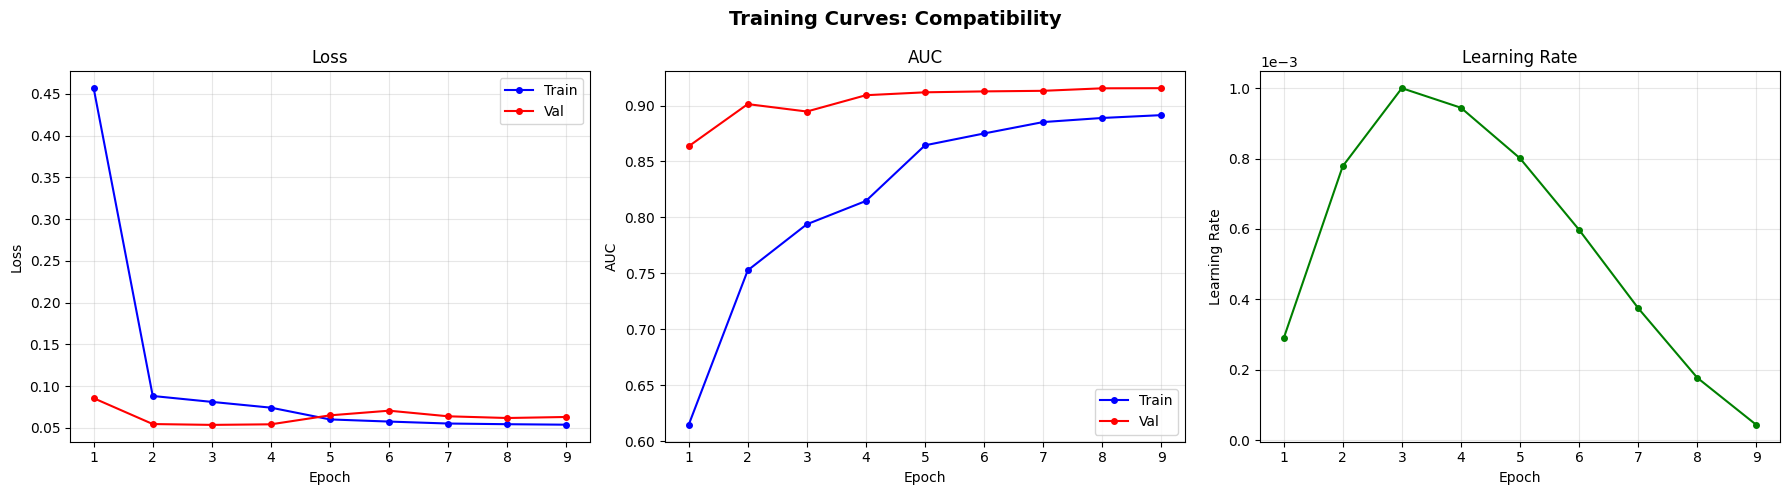


📊 Compatibility Summary:
  Best Epoch: 8
  Best Val AUC: 0.9155386666666667
  Total Training Time: 0.5h


In [29]:
plot_training_curves(
    "/kaggle/working/checkpoints/compatibility/checkpoint_best.pth",
    "Compatibility"
)

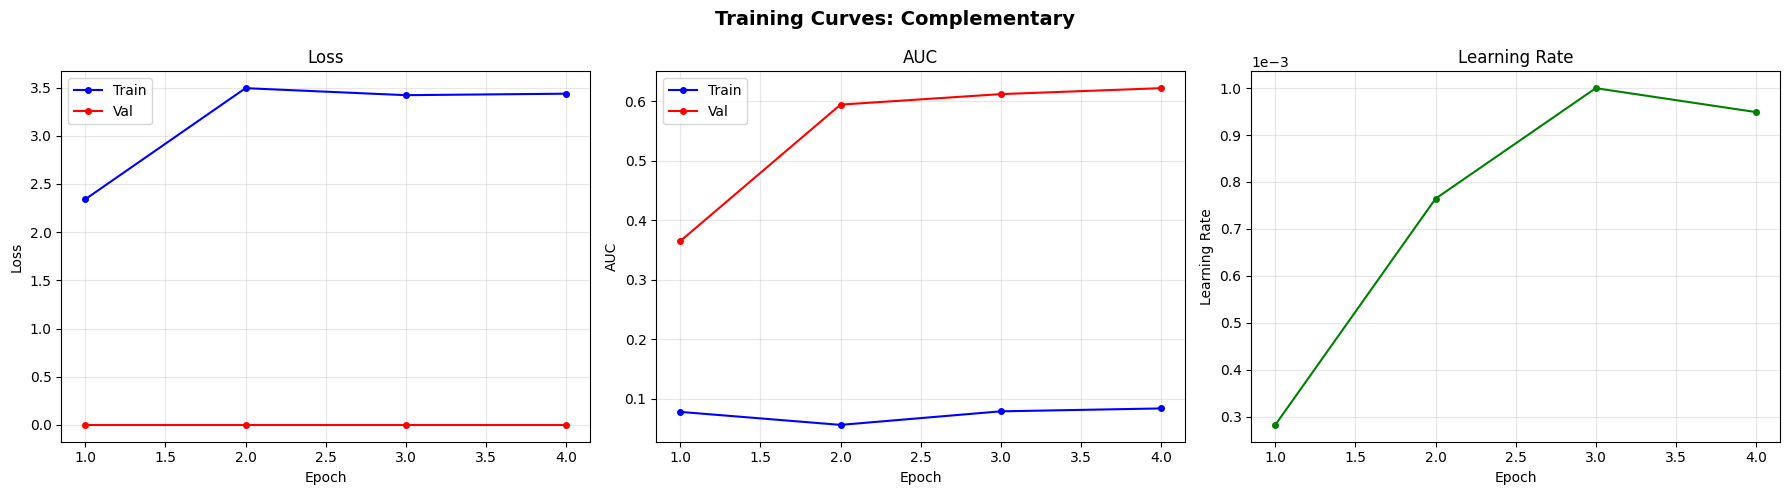


📊 Complementary Summary:
  Best Epoch: 3
  Best Val AUC: 0.621666669845581
  Total Training Time: 0.1h


In [30]:
plot_training_curves(
    "/kaggle/working/checkpoints/complementary/checkpoint_best.pth",
    "Complementary"
)

In [31]:
# Finish WandB run
wandb.finish()

print("\n🎉 Training pipeline complete!")
print("Checkpoints saved to /kaggle/working/checkpoints/")
print("Download them from the Output tab or create a Kaggle Dataset.")

wandb: updating run metadata
wandb: 
wandb: Run history:
wandb:        compatibility/epoch ▁▂▃▃▄▅▆▆▇█
wandb: compatibility/epoch_time_s ▃▁▅▄▇▆▃▄▇█
wandb:           compatibility/lr ▃▆██▇▅▄▂▁▁
wandb:    compatibility/train_auc ▁▄▆▆▇█████
wandb:   compatibility/train_loss █▂▁▁▁▁▁▁▁▁
wandb:      compatibility/val_auc ▁▆▅▇██████
wandb:     compatibility/val_loss █▁▁▁▄▅▃▃▃▃
wandb:        complementary/epoch ▁▂▃▃▄▅▆▆▇█
wandb: complementary/epoch_time_s ▆▇▇█▅█▆▂▁▃
wandb:           complementary/lr ▃▆██▇▅▄▂▁▁
wandb:                         +4 ...
wandb: 
wandb: Run summary:
wandb:        compatibility/epoch 9
wandb: compatibility/epoch_time_s 213.83833
wandb:           compatibility/lr 0.0
wandb:    compatibility/train_auc 0.8905
wandb:   compatibility/train_loss 0.05389
wandb:      compatibility/val_auc 0.91551
wandb:     compatibility/val_loss 0.06261
wandb:        complementary/epoch 9
wandb: complementary/epoch_time_s 115.40967
wandb:           complementary/lr 0.0
wandb:                  


🎉 Training pipeline complete!
Checkpoints saved to /kaggle/working/checkpoints/
Download them from the Output tab or create a Kaggle Dataset.


## Evaluation on Test Set
Runs the same tests as the repo's `2_test_compatibility.py` and `3_test_complementary.py`
on the **test** split. Results are compared against the repo's reported baselines.

In [32]:
print("\n" + "=" * 70)
print("EVALUATION ON TEST SET")
print("=" * 70)

# ============================================================
# Test 1: Compatibility Prediction (CP) - Test Split
# ============================================================
print("\n" + "-" * 60)
print("TEST: Compatibility Prediction (CP)")
print("-" * 60)

# Load best compatibility checkpoint
compat_best_path = "/kaggle/working/checkpoints/compatibility/checkpoint_best.pth"
if Path(compat_best_path).exists():
    # Load model from our best checkpoint
    compat_test_ckpt = torch.load(compat_best_path, map_location="cpu")
    compat_test_model = load_model(
        model_type='clip',
        checkpoint='checkpoints/compatibillity_clip_best.pth',
        image_only=True
    )
    # Load our trained weights
    missing, unexpected = compat_test_model.load_state_dict(
        compat_test_ckpt['model'], strict=False
    )
    if missing:
        print(f"  Warning - Missing keys: {missing}")
    compat_test_model.eval()
    device = next(compat_test_model.parameters()).device

    # Create test dataset
    test_compat = polyvore.PolyvoreCompatibilityDataset(
        dataset_type='disjoint',
        dataset_split='test',
        embedding_dict=embedding_dict
    )
    test_compat_loader = DataLoader(
        dataset=test_compat, batch_size=512, shuffle=False,
        num_workers=0, collate_fn=collate_fn.cp_collate_fn
    )
    print(f"  Test samples: {len(test_compat)}")

    # Run evaluation
    all_preds, all_labels = [], []
    with torch.no_grad():
        pbar = tqdm(test_compat_loader, desc='[Test] Compatibility')
        for data in pbar:
            labels = torch.tensor([float(l) for l in data['label']], dtype=torch.float32).to(device)
            preds = compat_test_model(data['query'], use_precomputed_embedding=True).squeeze(1)

            all_preds.append(preds.detach())
            all_labels.append(labels.detach())

            batch_score = compute_cp_scores(preds.detach(), labels.detach())
            pbar.set_postfix(auc=f"{batch_score.get('auc', 0):.4f}")

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    cp_test_scores = compute_cp_scores(all_preds, all_labels)

    print(f"\n  Compatibility Test Results:")
    print(f"     AUC:       {cp_test_scores['auc']:.4f}")
    print(f"     Accuracy:  {cp_test_scores['acc']:.4f}")
    print(f"     Precision: {cp_test_scores['precision']:.4f}")
    print(f"     Recall:    {cp_test_scores['recall']:.4f}")
    print(f"     F1:        {cp_test_scores['f1']:.4f}")

    # Save results
    cp_result_dir = Path("/kaggle/working/results/compatibility")
    cp_result_dir.mkdir(parents=True, exist_ok=True)
    with open(cp_result_dir / "test_results.json", 'w') as f:
        json.dump(cp_test_scores, f, indent=4)
    print(f"  Results saved to {cp_result_dir / 'test_results.json'}")

    # Log to WandB
    try:
        wandb.log({"test/compatibility_" + k: v for k, v in cp_test_scores.items()})
    except Exception:
        pass
else:
    cp_test_scores = None
    print(f"  No compatibility checkpoint found at {compat_best_path}")

# ============================================================
# Test 2: Complementary Item Retrieval (CIR / FITB) - Test Split
# ============================================================
print("\n" + "-" * 60)
print("TEST: Complementary Item Retrieval (Fill-in-the-Blank)")
print("-" * 60)

compl_best_path = "/kaggle/working/checkpoints/complementary/checkpoint_best.pth"
if Path(compl_best_path).exists():
    # Load model from our best checkpoint
    compl_test_ckpt = torch.load(compl_best_path, map_location="cpu")
    compl_test_model = load_model(
        model_type='clip',
        checkpoint='checkpoints/complementary_clip_best.pth',
        image_only=True
    )
    missing, unexpected = compl_test_model.load_state_dict(
        compl_test_ckpt['model'], strict=False
    )
    if missing:
        print(f"  Warning - Missing keys: {missing}")
    compl_test_model.eval()
    device = next(compl_test_model.parameters()).device

    # Create test dataset
    test_fitb = polyvore.PolyvoreFillInTheBlankDataset(
        dataset_type='disjoint',
        dataset_split='test',
        embedding_dict=embedding_dict
    )
    test_fitb_loader = DataLoader(
        dataset=test_fitb, batch_size=64, shuffle=False,
        num_workers=0, collate_fn=collate_fn.fitb_collate_fn
    )
    print(f"  Test samples: {len(test_fitb)}")

    # Run evaluation
    all_preds, all_labels = [], []
    with torch.no_grad():
        pbar = tqdm(test_fitb_loader, desc='[Test] Fill-in-the-Blank')
        for data in pbar:
            batched_q_emb = compl_test_model(
                data['query'], use_precomputed_embedding=True
            ).unsqueeze(1)
            batched_c_embs = compl_test_model(
                sum(data['candidates'], []), use_precomputed_embedding=True
            )
            batched_c_embs = batched_c_embs.view(-1, 4, batched_c_embs.shape[1])

            dists = torch.norm(batched_q_emb - batched_c_embs, dim=-1)
            preds = torch.argmin(dists, dim=-1)
            labels = torch.tensor([int(l) for l in data['label']], device=device)

            all_preds.append(preds.detach())
            all_labels.append(labels.detach())

            batch_score = compute_cir_scores(preds.detach(), labels.detach())
            pbar.set_postfix(acc=f"{batch_score.get('acc', 0):.4f}")

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    cir_test_scores = compute_cir_scores(all_preds, all_labels)

    print(f"\n  Fill-in-the-Blank Test Results:")
    print(f"     Accuracy: {cir_test_scores['acc']:.4f}")

    # Save results
    cir_result_dir = Path("/kaggle/working/results/complementary")
    cir_result_dir.mkdir(parents=True, exist_ok=True)
    with open(cir_result_dir / "test_results.json", 'w') as f:
        json.dump(cir_test_scores, f, indent=4)
    print(f"  Results saved to {cir_result_dir / 'test_results.json'}")

    try:
        wandb.log({"test/complementary_" + k: v for k, v in cir_test_scores.items()})
    except Exception:
        pass
else:
    cir_test_scores = None
    print(f"  No complementary checkpoint found at {compl_best_path}")


EVALUATION ON TEST SET

------------------------------------------------------------
TEST: Compatibility Prediction (CP)
------------------------------------------------------------


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

CLIPVisionModelWithProjection LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.embeddings.token_embedding.weight

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.lay

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.lay

[Info] New params (not in checkpoint): ['precomputed_no_text_emb']
Loaded model from checkpoint: checkpoints/complementary_clip_best.pth
  Test samples: 15145


[Test] Fill-in-the-Blank: 100%|██████████| 237/237 [01:51<00:00,  2.13it/s, acc=0.5610]


  Fill-in-the-Blank Test Results:
     Accuracy: 0.5996
  Results saved to /kaggle/working/results/complementary/test_results.json


In [33]:
print("\n" + "=" * 70)
print(f"{'FINAL TEST RESULTS SUMMARY':^70}")
print("=" * 70)

print("\n--- Compatibility Prediction (CP) ---")
print(f"{'Metric':<15} {'Ours (img-only)':>18} {'Note':>25}")
print("-" * 60)
if cp_test_scores:
    print(f"{'AUC':<15} {cp_test_scores['auc']:>18.4f} {'Higher is better':>25}")
    print(f"{'Accuracy':<15} {cp_test_scores['acc']:>18.4f} {' ':>25}")
    print(f"{'Precision':<15} {cp_test_scores['precision']:>18.4f} {' ':>25}")
    print(f"{'Recall':<15} {cp_test_scores['recall']:>18.4f} {' ':>25}")
    print(f"{'F1':<15} {cp_test_scores['f1']:>18.4f} {' ':>25}")
else:
    print("(not available)         N/A         No checkpoint found")

print("\n--- Complementary Item Retrieval (FITB) ---")
print(f"{'Metric':<15} {'Ours (img-only)':>18} {'Note':>25}")
print("-" * 60)
if cir_test_scores:
    print(f"{'Accuracy':<15} {cir_test_scores['acc']:>18.4f} {'Higher is better':>25}")
else:
    print("(not available)         N/A         No checkpoint found")

print("\nNotes:")
print("   - Our model uses image-only embeddings (512-dim) with concat adapter")
print("   - Original repo uses image+text embeddings (1024-dim)")
print("   - We use disjoint split; repo defaults to nondisjoint")
print("   - Some performance difference is expected due to image-only mode")

print("\nEvaluation complete!")
print("Results saved to /kaggle/working/results/")


                      FINAL TEST RESULTS SUMMARY                      

--- Compatibility Prediction (CP) ---
Metric             Ours (img-only)                      Note
------------------------------------------------------------
AUC                         0.8996          Higher is better
Accuracy                    0.7778                          
Precision                   0.9077                          
Recall                      0.6186                          
F1                          0.7358                          

--- Complementary Item Retrieval (FITB) ---
Metric             Ours (img-only)                      Note
------------------------------------------------------------
Accuracy                    0.5996          Higher is better

Notes:
   - Our model uses image-only embeddings (512-dim) with concat adapter
   - Original repo uses image+text embeddings (1024-dim)
   - We use disjoint split; repo defaults to nondisjoint
   - Some performance difference is expe